In [1]:
# VedantRajekar 23070521113

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import kagglehub
import os

# path to kaggle dataset
path = kagglehub.dataset_download("lespin/house-prices-dataset")
print("Path to dataset files:", path)
print("Files found:", os.listdir(path))

# Load the dataset (assuming 'train.csv' and 'test.csv' are in the downloaded path)
# The user's prompt implies 'house-prices-dataset' is the folder containing these. We will load train.csv for now.
try:
    train_df = pd.read_csv(f"{path}/train.csv")
    test_df = pd.read_csv(f"{path}/test.csv")
    print("Training data loaded successfully. First 5 rows:")
    display(train_df.head())
    print("\nTest data loaded successfully. First 5 rows:")
    display(test_df.head())
except FileNotFoundError:
    print("Error: train.csv or test.csv not found in the specified path.")
    print("Please ensure the dataset contains 'train.csv' and 'test.csv'.")

Using Colab cache for faster access to the 'house-prices-dataset' dataset.
Path to dataset files: /kaggle/input/house-prices-dataset
Files found: ['sample_submission.csv', 'data_description.txt', 'train.csv', 'test.csv']
Training data loaded successfully. First 5 rows:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



Test data loaded successfully. First 5 rows:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


### Data Preprocessing for Baseline Model

For a simple baseline model, we'll perform minimal preprocessing:
1. Handle missing values by dropping columns with too many NaNs and imputing numerical NaNs with the mean.
2. Encode categorical features using one-hot encoding.
3. Select relevant features and split the data into training and validation sets.


In [2]:
# Drop columns with more than 50% missing values
missing_threshold = 0.5 * len(train_df)
train_df_cleaned = train_df.dropna(axis=1, thresh=missing_threshold)
test_df_cleaned = test_df.dropna(axis=1, thresh=missing_threshold)

# Identify numerical and categorical columns
numerical_cols_train = train_df_cleaned.select_dtypes(include=np.number).columns.tolist()
categorical_cols_train = train_df_cleaned.select_dtypes(include='object').columns.tolist()

numerical_cols_test = test_df_cleaned.select_dtypes(include=np.number).columns.tolist()
categorical_cols_test = test_df_cleaned.select_dtypes(include='object').columns.tolist()

# Impute missing numerical values with the mean
for col in numerical_cols_train:
    if train_df_cleaned[col].isnull().any():
        train_df_cleaned[col] = train_df_cleaned[col].fillna(train_df_cleaned[col].mean())
for col in numerical_cols_test:
    if test_df_cleaned[col].isnull().any():
        test_df_cleaned[col] = test_df_cleaned[col].fillna(test_df_cleaned[col].mean())

# Handle categorical features: one-hot encoding
# Align columns between train and test after one-hot encoding
combined_df = pd.concat([train_df_cleaned.drop('SalePrice', axis=1), test_df_cleaned], ignore_index=True)
combined_df_encoded = pd.get_dummies(combined_df, columns=categorical_cols_train, drop_first=True, dummy_na=False)

train_processed = combined_df_encoded.iloc[:len(train_df_cleaned)]
test_processed = combined_df_encoded.iloc[len(train_df_cleaned):]

# Re-add SalePrice to the training data
train_processed['SalePrice'] = train_df_cleaned['SalePrice']

# Drop ID columns if they exist (they are typically not features)
if 'Id' in train_processed.columns:
    train_processed = train_processed.drop('Id', axis=1)
if 'Id' in test_processed.columns:
    test_processed = test_processed.drop('Id', axis=1)

print("Processed Training Data Shape:", train_processed.shape)
print("Processed Test Data Shape:", test_processed.shape)
print("First 5 rows of processed training data:")
display(train_processed.head())

Processed Training Data Shape: (1460, 234)
Processed Test Data Shape: (1459, 233)
First 5 rows of processed training data:


/tmp/ipykernel_1382/2676451704.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df_cleaned[col] = train_df_cleaned[col].fillna(train_df_cleaned[col].mean())
/tmp/ipykernel_1382/2676451704.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df_cleaned[col] = test_df_cleaned[col].fillna(test_df_cleaned[col].mean())
/tmp/ipykernel_1382/2676451704.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value ins

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,SalePrice
0,60,65.0,8450,7,5,2003,2003,196.0,706.0,0.0,...,False,False,False,True,False,False,False,True,False,208500
1,20,80.0,9600,6,8,1976,1976,0.0,978.0,0.0,...,False,False,False,True,False,False,False,True,False,181500
2,60,68.0,11250,7,5,2001,2002,162.0,486.0,0.0,...,False,False,False,True,False,False,False,True,False,223500
3,70,60.0,9550,7,5,1915,1970,0.0,216.0,0.0,...,False,False,False,True,False,False,False,False,False,140000
4,60,84.0,14260,8,5,2000,2000,350.0,655.0,0.0,...,False,False,False,True,False,False,False,True,False,250000


### Build and Train Baseline Linear Regression Model

In [3]:
# Define features (X) and target (y)
X = train_processed.drop('SalePrice', axis=1)
y = train_processed['SalePrice']

# Ensure X columns match between train and test after encoding (if not already handled)
# This is crucial for consistent feature sets
common_cols = list(set(X.columns) & set(test_processed.columns))
X = X[common_cols]
test_processed = test_processed[common_cols]

# Split the training data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")

# Initialize and train the Linear Regression model
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

print("\nBaseline Linear Regression model trained.")

X_train shape: (1168, 233)
y_train shape: (1168,)
X_val shape: (292, 233)
y_val shape: (292,)

Baseline Linear Regression model trained.


### Evaluate Baseline Model Performance

In [4]:
# Make predictions on the validation set
y_pred_baseline = baseline_model.predict(X_val)

# Evaluate the model
mse_baseline = mean_squared_error(y_val, y_pred_baseline)
rmse_baseline = np.sqrt(mse_baseline)
r2_baseline = r2_score(y_val, y_pred_baseline)

print(f"Baseline Model Performance on Validation Set:")
print(f"Mean Squared Error (MSE): {mse_baseline:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_baseline:.2f}")
print(f"R-squared (R2): {r2_baseline:.2f}")

Baseline Model Performance on Validation Set:
Mean Squared Error (MSE): 2724248139.00
Root Mean Squared Error (RMSE): 52194.33
R-squared (R2): 0.64


### Apply L1 (Lasso) Regularization

In [5]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# It's good practice to scale features for regularized models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Initialize and train the Lasso model (L1 regularization)
# We'll start with a default alpha, then can tune if needed.
lasso_model = Lasso(alpha=0.1, random_state=42, max_iter=10000) # Increased max_iter for convergence
lasso_model.fit(X_train_scaled, y_train)

# Make predictions on the validation set
y_pred_lasso = lasso_model.predict(X_val_scaled)

# Evaluate the Lasso model
mse_lasso = mean_squared_error(y_val, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_val, y_pred_lasso)

print(f"Lasso Model Performance on Validation Set (alpha=0.1):")
print(f"Mean Squared Error (MSE): {mse_lasso:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lasso:.2f}")
print(f"R-squared (R2): {r2_lasso:.2f}")

Lasso Model Performance on Validation Set (alpha=0.1):
Mean Squared Error (MSE): 2723274167.71
Root Mean Squared Error (RMSE): 52185.00
R-squared (R2): 0.64


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.736e+10, tolerance: 6.967e+08
  model = cd_fast.enet_coordinate_descent(


### Apply L2 (Ridge) Regularization

In [6]:
from sklearn.linear_model import Ridge

# Initialize and train the Ridge model (L2 regularization)
# We'll start with a default alpha, then can tune if needed.
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train_scaled, y_train)

# Make predictions on the validation set
y_pred_ridge = ridge_model.predict(X_val_scaled)

# Evaluate the Ridge model
mse_ridge = mean_squared_error(y_val, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_val, y_pred_ridge)

print(f"Ridge Model Performance on Validation Set (alpha=1.0):")
print(f"Mean Squared Error (MSE): {mse_ridge:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_ridge:.2f}")
print(f"R-squared (R2): {r2_ridge:.2f}")

Ridge Model Performance on Validation Set (alpha=1.0):
Mean Squared Error (MSE): 2407535233.63
Root Mean Squared Error (RMSE): 49066.64
R-squared (R2): 0.69


### Compare Performance (Baseline vs. Lasso vs. Ridge)

In [7]:
print("\n--- Model Performance Comparison ---")
print(f"Baseline Model   - RMSE: {rmse_baseline:.2f}, R2: {r2_baseline:.2f}")
print(f"Lasso Model      - RMSE: {rmse_lasso:.2f}, R2: {r2_lasso:.2f}")
print(f"Ridge Model      - RMSE: {rmse_ridge:.2f}, R2: {r2_ridge:.2f}")

# Optionally, visualize coefficients to see feature selection by Lasso
# if 'X' was not already scaled, ensure it's handled here
print("\nTop 10 features by absolute Lasso coefficient:")
lasso_coeffs = pd.Series(lasso_model.coef_, index=X.columns)
print(lasso_coeffs.abs().sort_values(ascending=False).head(10))


--- Model Performance Comparison ---
Baseline Model   - RMSE: 52194.33, R2: 0.64
Lasso Model      - RMSE: 52185.00, R2: 0.64
Ridge Model      - RMSE: 49066.64, R2: 0.69

Top 10 features by absolute Lasso coefficient:
RoofMatl_CompShg    85610.299223
RoofMatl_Tar&Grv    59447.857837
GarageQual_TA       46296.020447
RoofMatl_WdShngl    40131.026369
GarageCond_TA       37610.410035
RoofMatl_WdShake    34310.466881
GarageQual_Fa       27486.660942
RoofMatl_Metal      21054.818382
RoofMatl_Roll       19967.340929
GarageCond_Fa       19288.224656
dtype: float64


### Implement Dropout with a Neural Network Model

For Dropout, we need a neural network architecture. We will build a simple Multi-Layer Perceptron (MLP) using TensorFlow/Keras and add Dropout layers.

In [8]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler

# It's crucial to scale data for neural networks
# We will re-initialize scaler and scale X_train and X_val again to ensure consistency
# if the previous scaling for Lasso/Ridge was not fully executed.
scaler_nn = StandardScaler()
X_train_scaled_nn = scaler_nn.fit_transform(X_train)
X_val_scaled_nn = scaler_nn.transform(X_val)

# Define the neural network model with Dropout
def build_nn_model_with_dropout():
    model = keras.Sequential([
        layers.Input(shape=(X_train_scaled_nn.shape[1],)), # Input layer
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3), # Dropout layer with 30% dropout rate
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3), # Another Dropout layer
        layers.Dense(1) # Output layer for regression (single value prediction)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

nn_dropout_model = build_nn_model_with_dropout()
nn_dropout_model.summary()

# Train the model
history_dropout = nn_dropout_model.fit(
    X_train_scaled_nn, y_train,
    validation_data=(X_val_scaled_nn, y_val),
    epochs=100, # Number of epochs can be tuned
    batch_size=32,
    verbose=0 # Set to 1 or 2 for progress updates
)

print("Neural Network with Dropout trained.")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        29,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,273 (149.50 KB)

 Trainable params: 38,273 (149.50 KB)

 Non-trainable params: 0 (0.00 B)

Neural Network with Dropout trained.


### Evaluate Dropout Model Performance

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Dropout Model Performance on Validation Set:
Mean Squared Error (MSE): 1800921344.00
Root Mean Squared Error (RMSE): 42437.26
R-squared (R2): 0.77


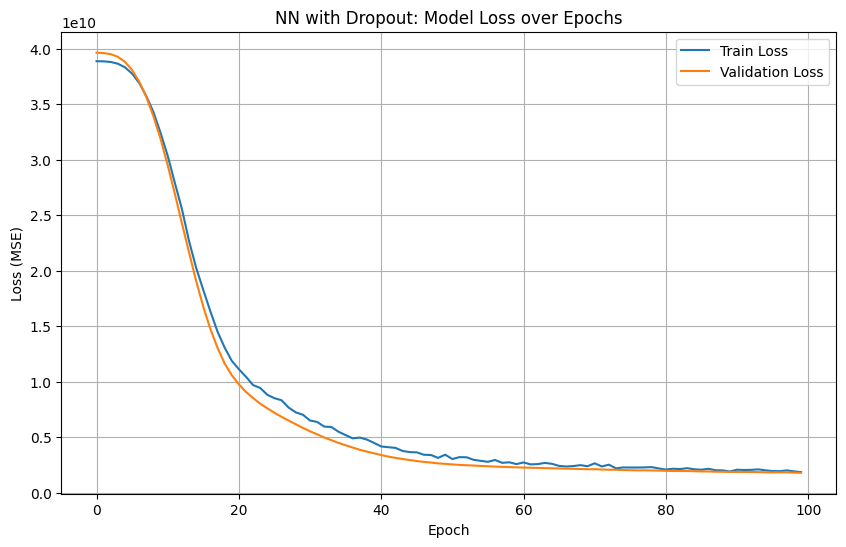

In [9]:
# Make predictions on the validation set
y_pred_dropout = nn_dropout_model.predict(X_val_scaled_nn).flatten()

# Evaluate the Dropout model
mse_dropout = mean_squared_error(y_val, y_pred_dropout)
rmse_dropout = np.sqrt(mse_dropout)
r2_dropout = r2_score(y_val, y_pred_dropout)

print(f"Dropout Model Performance on Validation Set:")
print(f"Mean Squared Error (MSE): {mse_dropout:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_dropout:.2f}")
print(f"R-squared (R2): {r2_dropout:.2f}")

# Plot training history (loss over epochs)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history_dropout.history['loss'], label='Train Loss')
plt.plot(history_dropout.history['val_loss'], label='Validation Loss')
plt.title('NN with Dropout: Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

### Final Performance Comparison (Baseline vs. L1 vs. L2 vs. Dropout)

In [10]:
print("\n--- Overall Model Performance Comparison ---")
print(f"Baseline Model   - RMSE: {rmse_baseline:.2f}, R2: {r2_baseline:.2f}")
print(f"Lasso Model      - RMSE: {rmse_lasso:.2f}, R2: {r2_lasso:.2f}")
print(f"Ridge Model      - RMSE: {rmse_ridge:.2f}, R2: {r2_ridge:.2f}")
print(f"Dropout NN Model - RMSE: {rmse_dropout:.2f}, R2: {r2_dropout:.2f}")

print("\nKey takeaway: Compare these metrics to understand how each technique impacts model performance and overfitting. Lower RMSE and higher R2 generally indicate better performance.")


--- Overall Model Performance Comparison ---
Baseline Model   - RMSE: 52194.33, R2: 0.64
Lasso Model      - RMSE: 52185.00, R2: 0.64
Ridge Model      - RMSE: 49066.64, R2: 0.69
Dropout NN Model - RMSE: 42437.26, R2: 0.77

Key takeaway: Compare these metrics to understand how each technique impacts model performance and overfitting. Lower RMSE and higher R2 generally indicate better performance.


### Detailed Performance Metrics for Dropout Neural Network

In [11]:
# Get the last epoch's metrics from the training history
final_train_loss = history_dropout.history['loss'][-1]
final_val_loss = history_dropout.history['val_loss'][-1]
final_train_mae = history_dropout.history['mae'][-1]
final_val_mae = history_dropout.history['val_mae'][-1]

print(f"Dropout Neural Network - Final Training Loss (MSE): {final_train_loss:.2f}")
print(f"Dropout Neural Network - Final Validation Loss (MSE): {final_val_loss:.2f}")
print(f"Dropout Neural Network - Final Training MAE: {final_train_mae:.2f}")
print(f"Dropout Neural Network - Final Validation MAE: {final_val_mae:.2f}")

Dropout Neural Network - Final Training Loss (MSE): 1855419648.00
Dropout Neural Network - Final Validation Loss (MSE): 1800921344.00
Dropout Neural Network - Final Training MAE: 32292.84
Dropout Neural Network - Final Validation MAE: 29497.96
